# 01 — Exploração Inicial dos Dados

Notebook de análise exploratória para o Tech Challenge FIAP — Alfabetização no Brasil.

Fontes analisadas:
- **Metas e Resultados** (convertidos de Excel): indicadores por município e UF
- **Microdados AEEB 2025**: dados do INEP sobre alfabetização (TS_ALUNO, TS_ESTADO, TS_ITEM, TS_MUNICIPIO)
- **Microdados Censo Escolar 2024**: contexto escolar para enriquecimento


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


## 1. Metas e Resultados (Excel convertido → CSV)

Carregamos os CSVs convertidos das planilhas de metas e resultados por município e UF.


In [2]:
# Load and Inspect Data — Metas e Resultados
REPO_ROOT = Path().resolve().parent
DATA_DIR = REPO_ROOT.parent / "converted_csv"

# Arquivos disponíveis
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f.name)


resultados_e_metas_municipios_2025_v2_Divulga_o_Alfabet_Municipio.csv
resultados_e_metas_municipios_2025_v2_Vari_veis.csv
resultados_e_metas_ufs_2025_v1_Divulga_o_Alfabet_UF_e_Brasil.csv
resultados_e_metas_ufs_2025_v1_vari_veis.csv


In [3]:
# Carregar CSVs de metas e resultados
metas_mun = pd.read_csv(DATA_DIR / "resultados_e_metas_municipios_2025_v2_Divulga_o_Alfabet_Municipio.csv", dtype=str)
metas_mun_vars = pd.read_csv(DATA_DIR / "resultados_e_metas_municipios_2025_v2_Vari_veis.csv", dtype=str)
metas_uf = pd.read_csv(DATA_DIR / "resultados_e_metas_ufs_2025_v1_Divulga_o_Alfabet_UF_e_Brasil.csv", dtype=str)
metas_uf_vars = pd.read_csv(DATA_DIR / "resultados_e_metas_ufs_2025_v1_vari_veis.csv", dtype=str)

print("=== Metas Municípios ===")
print(f"Shape: {metas_mun.shape}")
print(f"Colunas: {list(metas_mun.columns)}")
print(metas_mun.head(3))

print("\n=== Variáveis Municípios ===")
print(f"Shape: {metas_mun_vars.shape}")
print(metas_mun_vars.head())


=== Metas Municípios ===
Shape: (5470, 18)
Colunas: ['ANO DA AVALIAÇÃO', 'CÓDIGO UF', 'SIGLA UF', 'CÓDIGO MUNICÍPIO', 'NOME DO MUNICÍPIO', 'REDE', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2023 (1)', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2024 (1)', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)', 'META 2024 (2)', 'META 2025', 'META 2026', 'META 2027', 'META 2028', 'META 2029', 'META 2030', 'NIVEL ALFABETIZAÇÃO', 'PERCENTUAL DE PARTICIPAÇÃO']
  ANO DA AVALIAÇÃO CÓDIGO UF SIGLA UF CÓDIGO MUNICÍPIO      NOME DO MUNICÍPIO  \
0              ANO     CO_UF    SG_UF     CO_MUNICIPIO           NO_MUNICIPIO   
1             2025        11       RO          1100015  Alta Floresta D'Oeste   
2             2025        11       RO          1100023              Ariquemes   

         REDE PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2023 (1)  \
0  NO_TP_REDE                     PC_ALUNO_ALFABETIZADO_2023   
1   MUNICIPAL                                             65   
2   MUNICIPAL                         

## 2. Microdados AEEB 2025

Base principal do INEP com indicadores de alfabetização. Vamos inspecionar os schemas e amostras.


In [5]:
# Load and Inspect Data — Microdados AEEB 2025
AEEB_DIR = REPO_ROOT.parent / "microdados_AEEB_2025" / "DADOS"

aeeb_files = {
    "TS_ALUNO": AEEB_DIR / "TS_ALUNO.csv",
    "TS_ESTADO": AEEB_DIR / "TS_ESTADO.csv",
    "TS_ITEM": AEEB_DIR / "TS_ITEM.csv",
    "TS_MUNICIPIO": AEEB_DIR / "TS_MUNICIPIO.csv",
}

for name, path in aeeb_files.items():
    print(f"\n=== {name} ===")
    if not path.exists():
        print(f"Arquivo não encontrado: {path}")
        continue
    # Ler apenas as primeiras linhas para inspeção rápida
    df = pd.read_csv(path, nrows=5, dtype=str, encoding="utf-8", sep=";")
    print(f"Tamanho: {path.stat().st_size / 1024 / 1024:.1f} MB")
    print(f"Colunas ({len(df.columns)}): {list(df.columns)}")
    print(df.head(2))


=== TS_ALUNO ===
Tamanho: 257.7 MB
Colunas (27): ['NU_ANO_AVALIACAO', 'CO_UF', 'SG_UF', 'ID_ALUNO', 'TP_SERIE', 'ID_ESCOLA', 'TP_DEPENDENCIA', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP', 'CO_CADERNO_LP', 'CO_BLOCO_1', 'TX_RESPOSTA_BLOCO_1', 'TX_GABARITO_BLOCO_1', 'CO_BLOCO_2', 'TX_RESPOSTA_BLOCO_2', 'TX_GABARITO_BLOCO_2', 'CO_BLOCO_3', 'TX_RESPOSTA_BLOCO_3', 'TX_GABARITO_BLOCO_3', 'CO_BLOCO_4', 'TX_RESPOSTA_BLOCO_4', 'TX_GABARITO_BLOCO_4', 'VL_PESO_ALUNO_LP', 'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO']
  NU_ANO_AVALIACAO CO_UF SG_UF  ID_ALUNO TP_SERIE ID_ESCOLA TP_DEPENDENCIA  \
0             2025    11    RO  11000677        2  60000060              3   
1             2025    11    RO  11000678        2  60000060              3   

  CO_MUNICIPIO NO_MUNICIPIO IN_PRESENCA_LP IN_PREENCHIMENTO_LP CO_CADERNO_LP  \
0      1100023    Ariquemes              1                   1             8   
1      1100023    Ariquemes              1                   1        

## 3. Microdados Censo Escolar 2024

Base auxiliar para enriquecimento com contexto escolar (escola, turma, matrícula).


In [6]:
# Load and Inspect Data — Microdados Censo Escolar 2024
CENSO_DIR = REPO_ROOT.parent / "microdados_censo_escolar_2024" / "microdados_censo_escolar_2024_defeso" / "dados"

censo_path = CENSO_DIR / "microdados_ed_basica_2024.csv"
suplemento_path = CENSO_DIR / "suplemento_cursos_tecnicos_2024.csv"

print(f"=== Censo Escolar 2024 ===")
print(f"Arquivo: {censo_path}")
print(f"Tamanho: {censo_path.stat().st_size / 1024 / 1024:.1f} MB")

# Ler amostra para inspeção
df_censo = pd.read_csv(censo_path, nrows=5, dtype=str, encoding="latin-1", sep=";")
print(f"Colunas ({len(df_censo.columns)}): {list(df_censo.columns[:20])}...")
print(df_censo.head(2))

if suplemento_path.exists():
    print(f"\n=== Suplemento Cursos Técnicos ===")
    df_sup = pd.read_csv(suplemento_path, nrows=5, dtype=str, encoding="latin-1", sep=";")
    print(f"Shape: {df_sup.shape}")
    print(df_sup.head(2))


=== Censo Escolar 2024 ===
Arquivo: C:\Users\icaro\OneDrive\Área de Trabalho\Projetos\FIAP\Desafio2\microdados_censo_escolar_2024\microdados_censo_escolar_2024_defeso\dados\microdados_ed_basica_2024.csv
Tamanho: 207.8 MB
Colunas (426): ['NU_ANO_CENSO', 'NO_REGIAO', 'CO_REGIAO', 'NO_UF', 'SG_UF', 'CO_UF', 'NO_MUNICIPIO', 'CO_MUNICIPIO', 'NO_REGIAO_GEOG_INTERM', 'CO_REGIAO_GEOG_INTERM', 'NO_REGIAO_GEOG_IMED', 'CO_REGIAO_GEOG_IMED', 'NO_MESORREGIAO', 'CO_MESORREGIAO', 'NO_MICRORREGIAO', 'CO_MICRORREGIAO', 'NO_DISTRITO', 'CO_DISTRITO', 'NO_ENTIDADE', 'CO_ENTIDADE']...
  NU_ANO_CENSO NO_REGIAO CO_REGIAO     NO_UF SG_UF CO_UF  \
0         2024     Norte         1  Rondônia    RO    11   
1         2024     Norte         1  Rondônia    RO    11   

            NO_MUNICIPIO CO_MUNICIPIO NO_REGIAO_GEOG_INTERM  \
0  Alta Floresta D'Oeste      1100015             Ji-Paraná   
1  Alta Floresta D'Oeste      1100015             Ji-Paraná   

  CO_REGIAO_GEOG_INTERM NO_REGIAO_GEOG_IMED CO_REGIAO_GEOG

## 4. Estatísticas Descritivas e Qualidade dos Dados

Resumo de volume, nulos e consistência das fontes carregadas.


In [8]:
# Data Cleaning and Preprocessing — Resumo de qualidade
print("=" * 60)
print("RESUMO DE QUALIDADE DOS DADOS")
print("=" * 60)

# Metas Municípios — limpar header duplicado
metas_mun_clean = metas_mun.iloc[1:].copy()
print(f"\nMetas Municípios: {metas_mun_clean.shape[0]} registros, {metas_mun_clean.shape[1]} colunas")
print(f"Colunas: {list(metas_mun_clean.columns)}")

# Verificar nulos
nulos = metas_mun_clean.isnull().sum()
print(f"\nColunas com nulos: {nulos[nulos > 0].to_dict()}")

# TS_MUNICIPIO — amostra de estatísticas (encoding latin-1)
print(f"\nTS_MUNICIPIO (AEEB): {pd.read_csv(AEEB_DIR / 'TS_MUNICIPIO.csv', sep=';', dtype=str, encoding='latin-1').shape[0]} registros")
print(f"TS_ALUNO (AEEB): {pd.read_csv(AEEB_DIR / 'TS_ALUNO.csv', sep=';', dtype=str, encoding='latin-1').shape[0]} registros")

# Censo — tamanho
print(f"\nCenso Escolar 2024: ~{censo_path.stat().st_size / 1024 / 1024:.0f} MB")
print(f"Colunas no Censo: {len(df_censo.columns)}")

RESUMO DE QUALIDADE DOS DADOS

Metas Municípios: 5469 registros, 18 colunas
Colunas: ['ANO DA AVALIAÇÃO', 'CÓDIGO UF', 'SIGLA UF', 'CÓDIGO MUNICÍPIO', 'NOME DO MUNICÍPIO', 'REDE', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2023 (1)', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2024 (1)', 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)', 'META 2024 (2)', 'META 2025', 'META 2026', 'META 2027', 'META 2028', 'META 2029', 'META 2030', 'NIVEL ALFABETIZAÇÃO', 'PERCENTUAL DE PARTICIPAÇÃO']

Colunas com nulos: {'ANO DA AVALIAÇÃO': 1, 'CÓDIGO UF': 3, 'SIGLA UF': 3, 'CÓDIGO MUNICÍPIO': 3, 'NOME DO MUNICÍPIO': 3, 'REDE': 3, 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2023 (1)': 164, 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2024 (1)': 165, 'PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)': 6, 'META 2024 (2)': 49, 'META 2025': 49, 'META 2026': 3, 'META 2027': 3, 'META 2028': 3, 'META 2029': 3, 'META 2030': 3, 'NIVEL ALFABETIZAÇÃO': 3, 'PERCENTUAL DE PARTICIPAÇÃO': 3}

TS_MUNICIPIO (AEEB): 12416 registros
TS_ALUNO (A

## 5. Visualização — Distribuição do Percentual de Alfabetização

Distribuição do percentual de alunos alfabetizados nos municípios (dados de 2025).


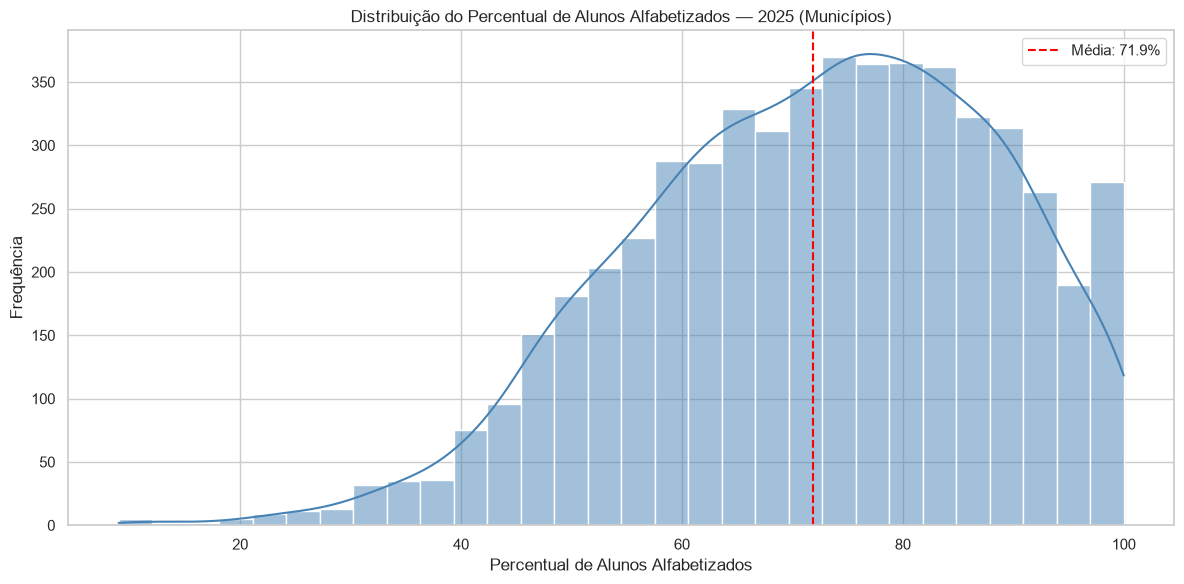

Média: 71.87%
Mediana: 73.00%
Desvio padrão: 16.27%


In [9]:
# Data Visualization — Distribuição do percentual de alfabetização 2025
# Converter para numérico e limpar
metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'] = pd.to_numeric(
    metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'], errors='coerce'
)

plt.figure(figsize=(12, 6))
sns.histplot(
    metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'].dropna(),
    bins=30,
    kde=True,
    color='steelblue'
)
plt.title('Distribuição do Percentual de Alunos Alfabetizados — 2025 (Municípios)')
plt.xlabel('Percentual de Alunos Alfabetizados')
plt.ylabel('Frequência')
plt.axvline(metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'].mean(), color='red', linestyle='--', label=f'Média: {metas_mun_clean["PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)"].mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Média: {metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'].mean():.2f}%")
print(f"Mediana: {metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'].median():.2f}%")
print(f"Desvio padrão: {metas_mun_clean['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)'].std():.2f}%")


## 6. Boxplot por UF — Percentual de Alfabetização 2025

Comparativo entre unidades federativas.


C:\Users\icaro\AppData\Local\Temp\ipykernel_6120\4249792173.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


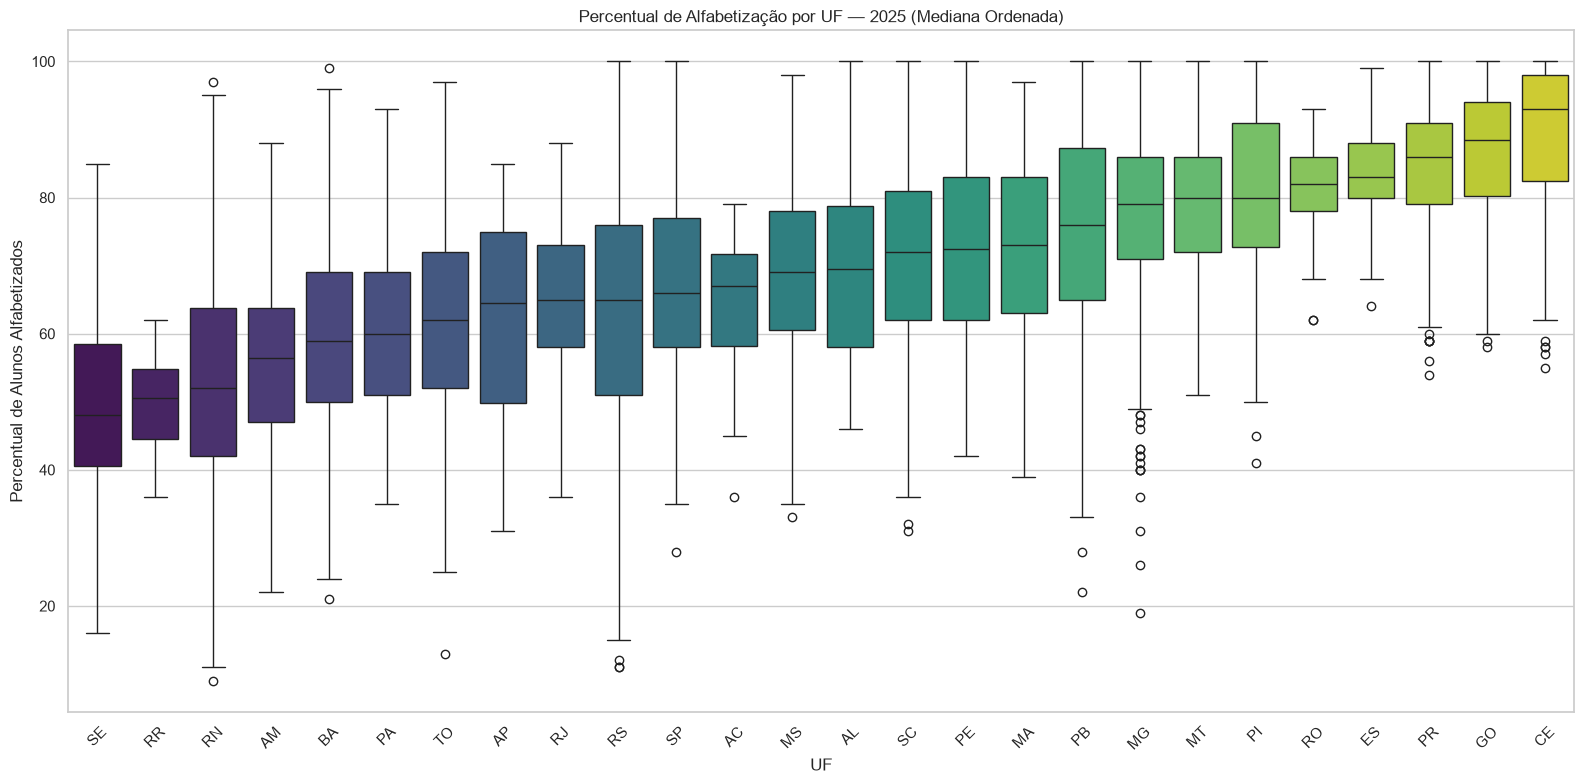

In [10]:
# Data Visualization — Boxplot por UF
plt.figure(figsize=(16, 8))
ufs_ordenadas = (
    metas_mun_clean.groupby('SIGLA UF')['PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)']
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=metas_mun_clean,
    x='SIGLA UF',
    y='PERCENTUAL DE ALUNOS ALFABETIZADOS  - 2025 (1)',
    order=ufs_ordenadas,
    palette='viridis'
)
plt.title('Percentual de Alfabetização por UF — 2025 (Mediana Ordenada)')
plt.xlabel('UF')
plt.ylabel('Percentual de Alunos Alfabetizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Insights e Próximos Passos

### Principais achados

| Métrica | Valor |
|---------|-------|
| Média nacional de alfabetização (2025) | **71.9%** |
| Mediana | **73.0%** |
| Desvio padrão | **16.3%** |
| UFs com menor mediana | SE, RR, RN, AM |
| UFs com maior mediana | CE, GO, PR, ES |

### Qualidade dos dados identificada
- **Metas/Resultados**: header duplicado (linha 0 = nomes técnicos), ~165 nulos em percentuais históricos
- **AEEB**: separador `;`, encoding `latin-1`, 2.2M+ registros de aluno
- **Censo**: 426 colunas, ~208 MB, separador `;`, encoding `latin-1`

### Próximos passos para a pipeline
1. **Bronze**: subir CSVs brutos para GCS e criar tabelas external/no BigQuery
2. **Silver**: limpar headers duplicados, padronizar nomes de colunas, tratar nulos
3. **Gold**: agregar indicador por município (AEEB + Metas) e enriquecer com Censo
